# EDA Temporal Cisps

Nesse notebook, faremos uma EDA direcionada a analisar o comportamento das séries temporais de cada CISP, buscando fazer agrupamentos e identificar padrões. Os objetivos aqui serão:

- Avaliar os padrões de evolução e verificar se se há diferença  notável entre as CISPs
- Executar o mesmo passo anterior, mas avaliando sazonalidade
- Identificar outliars

### Inicial

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from faz_mapa import faz_mapa
from IPython.display import IFrame
sequentialpalette = sns.color_palette('inferno')
qualitativepalette = sns.color_palette('colorblind')

sns.set_palette(palette=sequentialpalette)

sns.set_style("whitegrid")

In [104]:
## Carregando o datase
with open("../datasets/dataframe.pkl","rb") as file:
    df = pickle.load(file)
df = df[["cisp","mes","ano","mes_ano","furto_coletivo","roubo_em_coletivo"]]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6087 entries, 17389 to 37491
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   cisp               6087 non-null   int64         
 1   mes                6087 non-null   int64         
 2   ano                6087 non-null   int64         
 3   mes_ano            6087 non-null   datetime64[ns]
 4   furto_coletivo     6087 non-null   int64         
 5   roubo_em_coletivo  6087 non-null   int64         
dtypes: datetime64[ns](1), int64(5)
memory usage: 332.9 KB


In [105]:
df.describe()

,cisp,mes,ano,mes_ano,furto_coletivo,roubo_em_coletivo
count,6087.000000,6087.000000,6087.000000,6087,6087.000000,6087.000000
mean,24.037950,6.409069,2019.596846,2020-01-18 01:42:26.081813760,13.212420,11.551010
min,1.000000,1.000000,2014.000000,2014-01-01 00:00:00,0.000000,0.000000
25%,14.000000,3.000000,2017.000000,2017-01-01 00:00:00,5.000000,3.000000
50%,24.000000,6.000000,2020.000000,2020-01-01 00:00:00,10.000000,7.000000
75%,35.000000,9.000000,2023.000000,2023-02-01 00:00:00,18.000000,14.000000
max,45.000000,12.000000,2026.000000,2026-03-01 00:00:00,80.000000,189.000000
std,12.230414,3.477391,3.541934,NaN,11.383151,15.528831


A primeira noção é que não há valores faltantes. O período histórico, como esperado, vai de 2014 até 2026. 
Das informações de furto e roubo, vemos que existem períodos com nenhum dos dois, e para ambos os casos vemos que os valores máximos parecem outliers. No entanto, essa informação não nos diz muito, pois esse é um agregado das diferentes regiões. Precisamos quebrar o dataset em regiões para obter insights!

Outro ponto é, anteriormente na exploração, verificamos uma baixa correlação entre roubos e furtos em coletivos, que se concentram em bairros diferentes. Por isso, faremos as análises para os dois separadamente, visto que são dois dados com características diferentes.

Enquanto fazíamos a análise, encontramos algo que deixamos passar nessa etapa de processamento: existem cisps que não possuem a série temporal completa. 

In [106]:
k = df.groupby("cisp")[["cisp","ano"]].count()
k[-5:]
df[df["cisp"]==45]["ano"].value_counts()

ano
2014    12
2015    12
2016    12
2017    12
2018    12
Name: count, dtype: int64

Vemos que o culpado é a cisp 45, que só tem dados até 2018. Essa CISP não conta no dicionário que temos, o que indica que ela provavelmente foi extinta (absorvida em outras). Como nosso objetivo final é prever casos futuros, vamos excluir essa cisp.

In [107]:
df = df[df["cisp"]!=45]

###  Outliers nas timeseries

Vamos verificar, para cada cisp, se suas séries temproais são bem comportadas ou se possuem muitos outliers. 
Par encontrar outliers em uma série temporal, preciso de uma estratégia específica. Vamos utilizar o desvio padrão móvel: calcular a média e desvio padrão do último ano. caso o valor esteja acima ou abaixo de tres d.ps da media movel, o cosideramos um outlier.

[5, 7, 3, 4, 5, 7, 3, 0, 1, 1, 4, 4, 2, 4, 5, 6, 3, 5, 4, 2, 3, 3, 6, 5, 5, 2, 3, 3, 4, 4, 2, 3, 6, 1, 5, 4, 3, 4, 4, 3, 4]
3.707317073170732


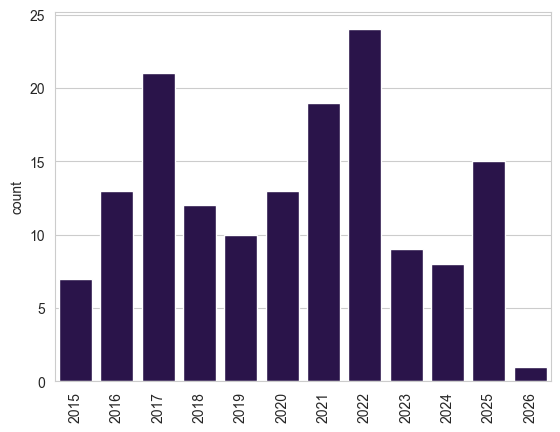

In [108]:
outs = []
years = []
for c in df["cisp"].unique():
    df_c = df[df["cisp"]==c]
    df_c = df_c.sort_values("mes_ano")
    med_movel = df_c['furto_coletivo'].rolling(window=12).mean().shift(1)
    dp_movel = df_c['furto_coletivo'].rolling(window=12).std().shift(1)
    #limite de 3 desvio padrao movel
    outliers = df_c[(df_c['furto_coletivo'] > med_movel+3*dp_movel) | (df_c['furto_coletivo'] < med_movel-3*dp_movel)]
    #if len(outliers):
        #print(outliers)
    outs.append(len(outliers))
    for elem in np.array(outliers["ano"]):
        years.append(elem)
print(outs)
print(np.mean(outs))
sns.barplot(pd.Series(years).value_counts())
plt.xticks(rotation=90)
plt.show()

Aqui tem duas informações importantes: a primeria é que coleitei, em média, 3.5 outliers pro cisp. É uma quantidade relativamente pequena até!
O segundo ponto (e mais importante) é que o ano de 2020, onde ocorreu a pandemia, tem poucoso outliers coletados. Isso faz sentido, dado que a média móvel acaba incorporando a mudança sistemica causada pela pandemia e não os cosnsidera fora do padrão.
A real é que os dados da pandemia são uma mudança sistêmica que esperamos que não ocorra denovo. Nesse sentido, os dados associados a ela são quase como lixo. Por isso, tomamos a decisão de substituí-los pela média dos valores observados para cada mês. Isso evita dados faltantes na série, facilitando o treinamento de modelos, e remove o viés causado pela pandemia. vamos considerar a pandemia o ano de 2020 a partir de março

<Axes: xlabel='mes_ano', ylabel='furto_coletivo'>

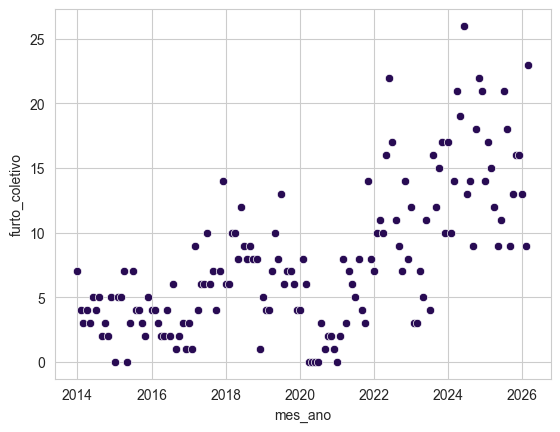

In [109]:
#visualização de como a pandemia afeta os dados em uma cisp
sns.scatterplot(data= df[df["cisp"]==26], x="mes_ano",y="furto_coletivo")

<Axes: xlabel='mes_ano', ylabel='furto_coletivo'>

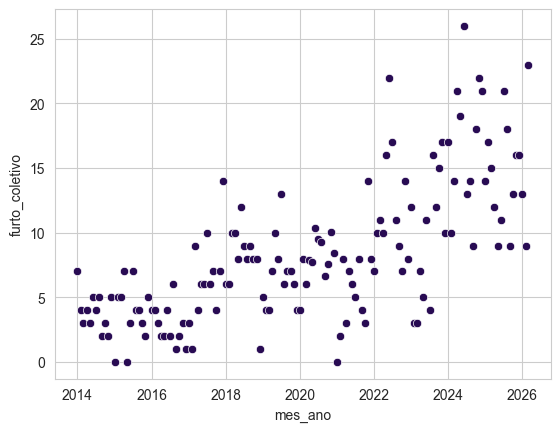

In [110]:
for col in ['roubo_em_coletivo', 'furto_coletivo']:
    periodo_pandemia = (df['ano'] == 2020) & (df['mes']>3)
    df.loc[periodo_pandemia, col] = np.nan
    medias = (df.groupby(['cisp', 'mes'])[col].transform('mean'))
    df[col] = df[col].fillna(medias)
sns.scatterplot(data= df[df["cisp"]==26], x="mes_ano",y="furto_coletivo")

A série parece mais contínua agora. Agora posso repetir o codigo anterior ara tratar outliers não pandêmicos. Vamos substituílos pela média histórica daquele mês + dois desvio padrão. Assim conseguimos manter a informação de se tratar de um mês com alta/ baixa criminalidade, porém caso seja um desvio muito brusco, o reduzimos para não enviesar tanto o modelo.

In [111]:
outs = []
for col in ["furto_coletivo","roubo_em_coletivo"]:
    for c in df["cisp"].unique():
        idx_c = df["cisp"] == c
        for mes in range(1, 13):
            idx = idx_c & (df["mes"] == mes)
            serie = df.loc[idx, col]
            media = serie.mean()
            dp = serie.std()
            limite_sup = media + 2 * dp
            limite_inf = media - 2 * dp
            mask_out = (
                (df.loc[idx, col] > limite_sup) |
                (df.loc[idx, col] < limite_inf)
            )
    
            outs.append(mask_out.sum())
            df.loc[
                idx & (df[col] > limite_sup),col] = limite_sup
            df.loc[
                idx & (df[col] < limite_inf),
                col            ] = limite_inf
print(np.mean(outs))

0.5386178861788617


Tiramos, em média, um outlier a cada 2 cisps. São poucos, o que indica que a série já era relativamente bem comportada. Agora nosso dataset está pronto para realizar análises.



### Furtos por CISP

Vamos incialmente verificar a evolução temporal dos furtos em diferentes CISPS. Vamos, inicialmente, ver como é a distribuição disso

Text(0.5, 1.0, 'Soma total de casos de roubo e furto por cisp')

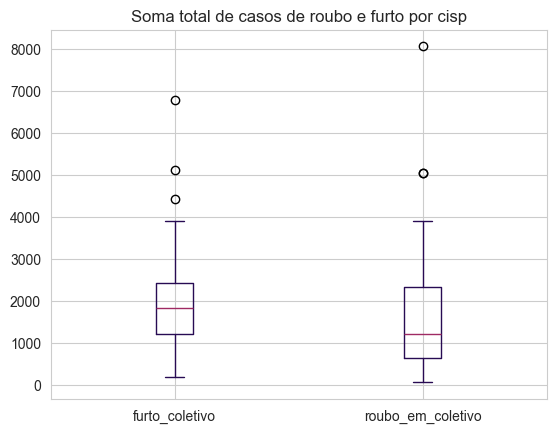

In [112]:
df.groupby("cisp")[["furto_coletivo", "roubo_em_coletivo"]].sum().plot.box()
plt.title("Soma total de casos de roubo e furto por cisp") 

Ambas as variáveis possuem medianas e valores típicos parecidos, e aparentam ter a distribuição skewed para cima, com a presença de algumas cisps outliars com grandes números de furtos. Verificando esses outlers:

In [113]:
aux = df.groupby("cisp")[["cisp","furto_coletivo","roubo_em_coletivo"]].sum()
outs_furtos = aux[aux["furto_coletivo"]>=4000]["cisp"]
outs_roubos = aux[aux["roubo_em_coletivo"]>=4000]["cisp"]
print(f"Outliers em furtos: {outs_furtos}")
print(f"Outliers em roubos: {outs_roubos}")

Outliers em furtos: cisp
10    1470
16    2352
32    4704
Name: cisp, dtype: int64
Outliers em roubos: cisp
17    2499
21    3087
39    5733
Name: cisp, dtype: int64


Verificando o dicionário, as cusos 10, 16 e 32 se referem a Botafogo, Barra da Tijuca e Jacarépagua. Já as 17, 21 e 39 são São Cristóvão, Bonsucesso e Pavuna. O que vemos aqui é a confirmação do que já tinhamos visto anteriormente: a baixa correção entre roubos e furtos se dá pois eles ocorrem em bairros de perfis diferentes. Furtos são prevalentes em regiões de maior poder aquisitivo, enquanto roubos são frequentes em zonas mais pobres. Isso reforça a necessidade de tratar os dois casos de forma separada.

### Avaliando Sazonalidade

Vamos verificar se diferentes regiões apresentam variações diferentes ao longo dos meses do ano. Para isso, normalizaremos os valores das séries e então faremos uma clusterização com base nas somas de roubos e furtos mensais em cada cisp. Caso hajam diferenças relevantes nos padrões temporais, o algoritmo as capturará em diferentes clusters.

9.059753358087908
15.752202201559431
12


<Axes: xlabel='mes'>

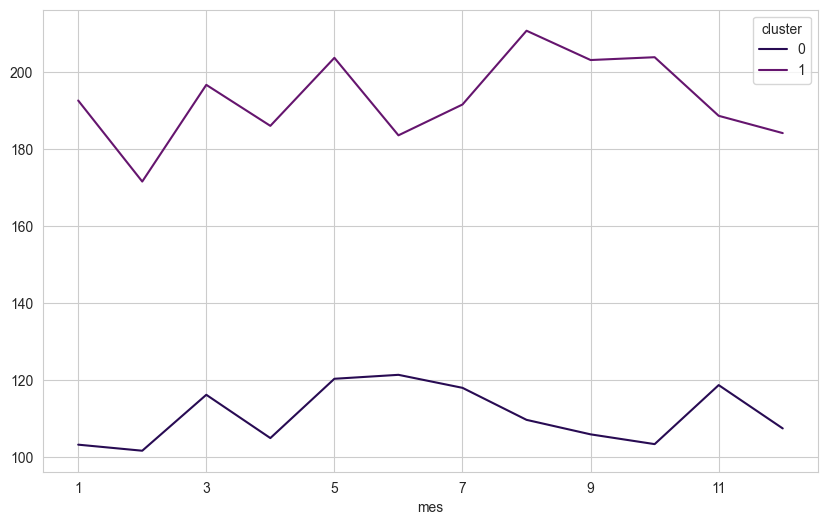

In [122]:
#matriz em q cada entrada é a soma de furtos da cisp i no mes j
df_cluster = df.groupby(["mes","cisp"])["furto_coletivo"].sum().reset_index().pivot_table(index="cisp",columns="mes",values="furto_coletivo",aggfunc="sum")
#normaliza
df_cluster_norm = df_cluster.sub(df_cluster.mean(axis=1), axis=0)

df_cluster_norm = df_cluster_norm.div(
    df_cluster.std(axis=1).replace(0, 1),
    axis=0
)
#aplicando kmeans com 3 clusters
n_clusters = 2
kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=409,
    n_init=10
)
clusters = kmeans.fit_predict(df_cluster_norm)
resultado = pd.DataFrame({
    "cisp": df_cluster.index,
    "cluster": clusters,
})
#printar a media de cada cluster para garantir que a clusterização não foi pelo valor absoluto. normalização funcionou!
for c in range(n_clusters):
    print(df[df["cisp"].isin(resultado[resultado["cluster"]==c]["cisp"])]["furto_coletivo"].mean())
df_cluster["cluster"] = np.array(resultado["cluster"])
print(len(df_cluster[df_cluster["cluster"]==0]))
medias_cluster = df_cluster.groupby("cluster").mean()
medias_cluster.T.plot(figsize=(10,6))

O que vemos aqui é que não há uma diferença clara na sazonalidade entre as regiões; existem algumas diferenças mas são poucas e é possível que sejam apenas ruído. Na realidade, vemos que os casos de furtos apresentam baixa sazonalidade.

13.360624312226028
10.190586884009504
19


<Axes: xlabel='mes'>

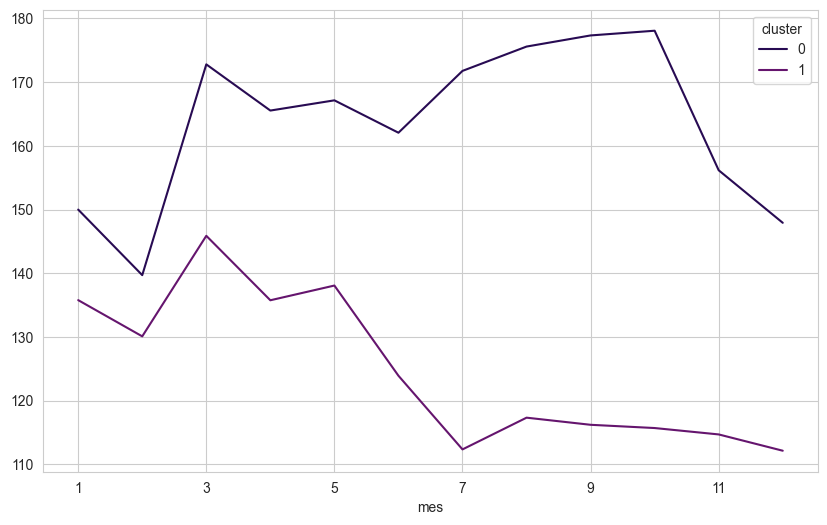

In [115]:
#matriz em q cada entrada é a soma de furtos da cisp i no mes j
df_cluster = df.groupby(["mes","cisp"])["roubo_em_coletivo"].sum().reset_index().pivot_table(index="cisp",columns="mes",values="roubo_em_coletivo",aggfunc="sum")
#normaliza
df_cluster_norm = df_cluster.sub(df_cluster.mean(axis=1), axis=0)

df_cluster_norm = df_cluster_norm.div(
    df_cluster.std(axis=1).replace(0, 1),
    axis=0
)
#aplicando kmeans com 3 clusters
n_clusters = 2
kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=404,
    n_init=10
)
clusters = kmeans.fit_predict(df_cluster_norm)
resultado = pd.DataFrame({
    "cisp": df_cluster.index,
    "cluster": clusters,
})
#printar a media de cada cluster para garantir que a clusterização não foi pelo valor absoluto. normalização funcionou!
for c in range(n_clusters):
    print(df[df["cisp"].isin(resultado[resultado["cluster"]==c]["cisp"])]["roubo_em_coletivo"].mean())
df_cluster["cluster"] = np.array(resultado["cluster"])
print(len(df_cluster[df_cluster["cluster"]==0]))
medias_cluster = df_cluster.groupby("cluster").mean()
medias_cluster.T.plot(figsize=(10,6))

No caso de roubos, vemos uma diferença mais marcante! Após o inicio do ano com o pico em março, os clusters tem comportamentos muito diferentes entre si. Avaliando seus integrantes:

In [116]:
df_cluster["cluster"].reset_index()
faz_mapa("Clusters de Sazonalidade de Roubos", "cluster", df_cluster["cluster"].reset_index(), ["cisp","cluster"],"cisp")
IFrame(src="./Clusters de Sazonalidade de Roubos.html", width=700, height=400)

Aqui temos um insight importante. O cluster 1, indica regiões onde há pico de ocorrências no verão. Dentro dele estão toda a zona sul carioca, recreio, e barra, que são regiões de praia com maior poder aquisitivo, é intuitivo terem mais roubos no verão. Outros bairros que seguem esse padrão são madureira, Ilha do Governador e Jacarépaguá. Já o cluester 0, com violência mais constante ao longo do ano, engloba a maioria das zonas norte e oeste.
Assim, vemos que a segurança em ônibus no Rio é um tema muito diferente dependendo da região, tanto no perfil dos crimes quanto na sazonalidade deles.

### Avaliando evolução temporal

Temos informações sobre a sazonalidade dos crimes ao longo do ano. No entanto, também gostaríamos de verificar as tendências. As regiões estão experenciando aumento ou diminuição na taxa de criminalidade ao longo dos anos? Vamos adotar a mesma estratégia da etapa anterior: clusterizar as cisps e visualizar a evolução média de cada cluster! No entanto, nesse caso as features serão anos em vez de meses. Vamos desconsiderar o ano de 2026 nessa análise, pois ainda está incompleto e naão tem os dados inteiros. Coemçando com avaliação de furtos:

11.99730310812085
15.873170303348408
22


<Axes: xlabel='ano'>

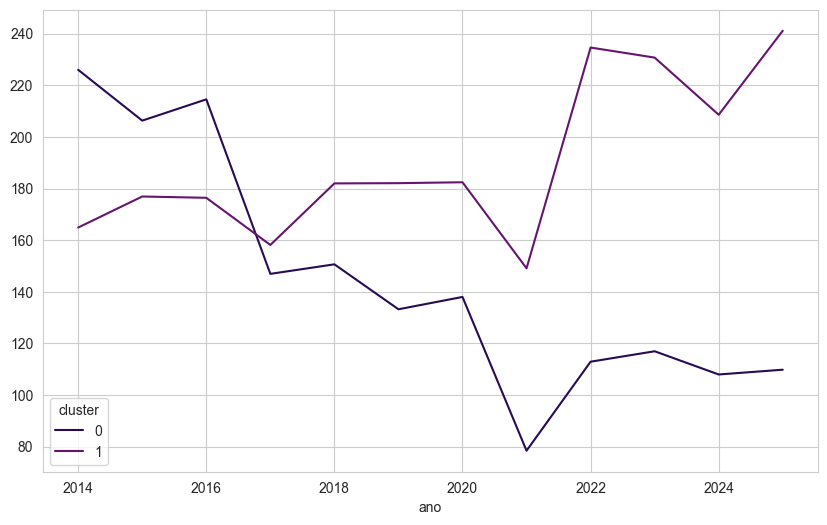

In [117]:
#matriz em q cada entrada é a soma de furtos da cisp i no ano j
df_pre_26 = df[df["ano"]<2026]
df_cluster = df_pre_26.groupby(["ano","cisp"])["furto_coletivo"].sum().reset_index().pivot_table(index="cisp",columns="ano",values="furto_coletivo",aggfunc="sum")
#normaliza
df_cluster_norm = df_cluster.sub(df_cluster.mean(axis=1), axis=0)

df_cluster_norm = df_cluster_norm.div(
    df_cluster.std(axis=1).replace(0, 1),
    axis=0
)
n_clusters = 2
kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=409,
    n_init=10
)
clusters = kmeans.fit_predict(df_cluster_norm)
resultado = pd.DataFrame({
    "cisp": df_cluster.index,
    "cluster": clusters,
})
#printar a media de cada cluster para garantir que a clusterização não foi pelo valor absoluto. normalização funcionou!
for c in range(n_clusters):
    print(df[df["cisp"].isin(resultado[resultado["cluster"]==c]["cisp"])]["furto_coletivo"].mean())
df_cluster["cluster"] = np.array(resultado["cluster"])
print(len(df_cluster[df_cluster["cluster"]==0]))
medias_cluster = df_cluster.groupby("cluster").mean()
medias_cluster.T.plot(figsize=(10,6))

Os clusters formados separam as regiões com tendência de subida das com tendencia de queda! Avaliando quais são:

In [118]:
df_cluster["cluster"].reset_index()
faz_mapa("Cluster de evolução de Furtos", "cluster", df_cluster["cluster"].reset_index(), ["cisp","cluster"],"cisp")
IFrame(src="./Cluster de evolução de Furtos.html", width=700, height=400)

O cluster 0 de descida inclui a zona sul, grande parte da zona oeste  e partes da zona norte como Vila da Pena, meier e Ilha.
Já o cluster 2, com tendenia de alta, inclui a zona sudoeste, região central, grande tijuca.

Esse é mais uma informação importante, que permite focar os esforços de segurança nas regiões que têm volumes crescentes.
Faremos agora o mesmo processo com dados de roubo:

12.313022200062319
15.507600828468814
22


<Axes: xlabel='ano'>

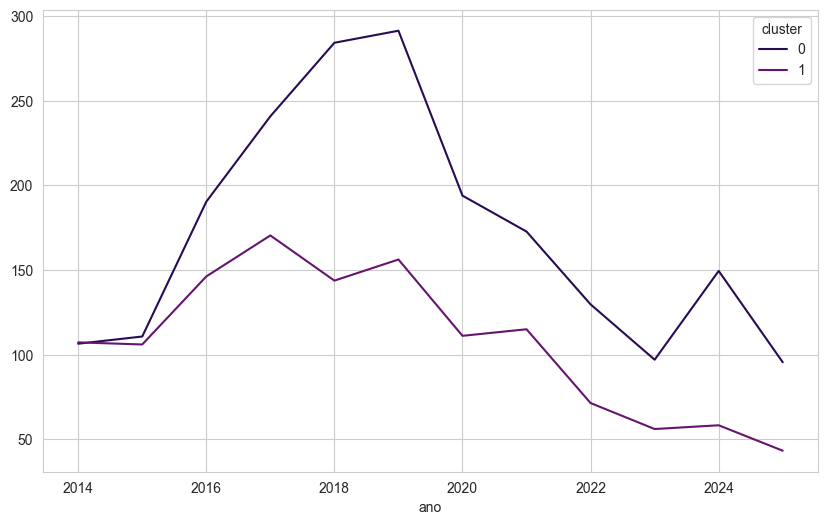

In [119]:
#matriz em q cada entrada é a soma de furtos da cisp i no ano j
df_pre_26 = df[df["ano"]<2026]
df_cluster = df_pre_26.groupby(["ano","cisp"])["roubo_em_coletivo"].sum().reset_index().pivot_table(index="cisp",columns="ano",values="roubo_em_coletivo",aggfunc="sum")
#normaliza
df_cluster_norm = df_cluster.sub(df_cluster.mean(axis=1), axis=0)

df_cluster_norm = df_cluster_norm.div(
    df_cluster.std(axis=1).replace(0, 1),
    axis=0
)
n_clusters = 2
kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=409,
    n_init=10
)
clusters = kmeans.fit_predict(df_cluster_norm)
resultado = pd.DataFrame({
    "cisp": df_cluster.index,
    "cluster": clusters,
})
#printar a media de cada cluster para garantir que a clusterização não foi pelo valor absoluto. normalização funcionou!
for c in range(n_clusters):
    print(df[df["cisp"].isin(resultado[resultado["cluster"]==c]["cisp"])]["furto_coletivo"].mean())
df_cluster["cluster"] = np.array(resultado["cluster"])
print(len(df_cluster[df_cluster["cluster"]==0]))
medias_cluster = df_cluster.groupby("cluster").mean()
medias_cluster.T.plot(figsize=(10,6))

Nesse caso, vemos que a forma das curvas é muito similar: um grande pico em 2019,mas a partir de então uma queda. Isso sugere que após a pandemia, o tipo de crime contra coletivos vem mudando, sendo cada vez mais furtos e não roubos. É importante mencionar que esse gráfico não significa que os roubos estejam caindo em todas as regiões, ele apenas indica que, caso existam regiões com tendência de crescimento, elas são poucas e não suficientes para gerar um cluster. Para isso, precisaremos analisar caso a caso.

## Conclusões

A principal conclusão que tiramos dessa análise é a clara diferença no perfil dos crimes em cada região. Isso fortalece nossa ideia que, para prever de forma acurada as taxas de crime contra ônibus, é fundamental que treinemos modelos específicos para cada região, para ser capaz de lidar com essas diferenças. Isso também evidencia a importância de tal modelo: entender o perfil de cada região é uma informação fundamental para organzizar as forças de segurança pública.
Os principais insights que obtemos foram:
- Roubos e furtos a ônibus são dois crimes com perfis muito diferentes, que afetam regiões distintas: furtos mais prevalentes em áreas de alto poder aquisitivo, roubos na periferia
- Os furtos a ônibus são crimes relativamtente constantes ao longo do ano, porém roubos apresentam forte sazonalidade, especialmente em regiões ricas, que têm picos claros no verão.
- Ao longo da série temporal, os crimes de roubo tem uma tendência de queda na maioria das regiões, enquanto em alguns locais a taxa de furto apresenta cresmiento.

## Próximas etapas

Com o tratamento dos dados feitos e tendo verificado a importância de separar as regiões e tipos de crimes, vamos treinar modelos específicos para prever os crimes em cada área. Assim, conseguiremos obter insights claros sobre o futuro do crime contra ônibus no Rio de Janeiro e poderemos orientar as foças da melhor forma possível.

In [125]:
##salvando o dataset limpo para trino
df.to_pickle("../datasets/df_treino.pkl")